In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# EJI EDA

In [2]:
# import EJI data
eji_data_raw = pd.read_csv('../Data/EJI/EJI_2024_United_States.csv', dtype={'GEOID': str})
eji_data_raw.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,1,1,20804,140000US01001020804,01001020804,1001020804,Autauga County,Alabama,AL,Census Tract 208.04; Autauga County; Alabama,...,0.0,0,0.0,156,2.8,26,0.5,0.0,-999,-999
1,1,3,10706,140000US01003010706,01003010706,1003010706,Baldwin County,Alabama,AL,Census Tract 107.06; Baldwin County; Alabama,...,0.0,0,0.0,77,1.8,0,0.0,0.0,-999,-999
2,1,3,11503,140000US01003011503,01003011503,1003011503,Baldwin County,Alabama,AL,Census Tract 115.03; Baldwin County; Alabama,...,0.0,0,0.0,232,2.8,0,0.0,0.0,-999,-999
3,1,3,11604,140000US01003011604,01003011604,1003011604,Baldwin County,Alabama,AL,Census Tract 116.04; Baldwin County; Alabama,...,0.0,0,0.0,34,1.2,33,1.1,0.0,-999,-999
4,1,5,950100,140000US01005950100,01005950100,1005950100,Barbour County,Alabama,AL,Census Tract 9501; Barbour County; Alabama,...,0.0,0,0.0,47,1.7,74,2.7,0.0,-999,-999


In [3]:
### preliminary cleanup for EJI data ###
# E_* variables are estimates
# EPL_* variables are percentile ranks for estimates
# RPL_* variables are percentile ranks for domains and overall score
# Keep E_ features and GEOID only
eji_est_i = eji_data_raw.columns.str.startswith("E_")
eji_geoid_i = eji_data_raw.columns == "GEOID"
eji_rpl_i = eji_data_raw.columns.isin(["RPL_EJI_CBM", "RPL_HVM", "RPL_SVM", "RPL_EBM", "RPL_CBM"])
eji_keep_i = eji_est_i | eji_geoid_i | eji_rpl_i
eji_data = eji_data_raw.loc[:, eji_keep_i]
eji_data = eji_data.drop(columns=['E_TOTPOP', 'E_DAYPOP']) # drop population vars -- not needed for regression
# replace -999 values with NaN
eji_data = eji_data.replace(-999, np.nan)
eji_data.head()

,GEOID,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,...,E_SWND,E_TRND,RPL_CBM,E_AFAM,E_HISP,E_ASIAN,E_AIAN,E_NHPI,E_TWOMORE,E_OTHERRACE
0,01001020804,0.0033,27.3,18.3372,5.8,1.1,12.2,18.0,3.5,1.5,...,1.2050,0.0278,0.1443,19.5,3.8,0.8,0.0,0.0,2.8,0.5
1,01003010706,0.1261,15.6,14.6876,1.3,5.4,14.0,10.0,8.3,5.7,...,1.4408,0.0000,0.6241,8.1,0.9,4.7,0.0,0.0,1.8,0.0
2,01003011503,0.6773,23.0,37.8453,16.4,1.0,35.1,36.8,18.6,10.0,...,1.5392,0.0278,0.6418,11.8,7.1,1.2,0.0,0.0,2.8,0.0
3,01003011604,0.5041,4.7,27.8750,7.1,5.3,5.2,10.6,8.7,17.9,...,1.5392,0.0000,0.8545,0.0,2.4,0.1,0.0,0.0,1.2,1.1
4,01005950100,0.7367,54.0,37.6837,14.0,14.7,14.8,20.9,7.7,27.7,...,1.3610,0.1389,0.7603,48.1,0.1,1.5,0.0,0.0,1.7,2.7


In [4]:
eji_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85188 entries, 0 to 85187
Data columns (total 58 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GEOID        85188 non-null  object 
 1   RPL_EJI_CBM  82740 non-null  float64
 2   E_MINRTY     83014 non-null  float64
 3   E_POV200     82818 non-null  float64
 4   E_NOHSDP     82993 non-null  float64
 5   E_UNEMP      82868 non-null  float64
 6   E_RENTER     82759 non-null  float64
 7   E_HOUBDN     82759 non-null  float64
 8   E_UNINSUR    82871 non-null  float64
 9   E_NOINT      82759 non-null  float64
 10  E_AGE65      83014 non-null  float64
 11  E_AGE17      83014 non-null  float64
 12  E_DISABL     82871 non-null  float64
 13  E_LIMENG     83014 non-null  float64
 14  E_MOBILE     82788 non-null  float64
 15  E_GROUPQ     83014 non-null  float64
 16  RPL_SVM      82744 non-null  float64
 17  E_OZONE      83509 non-null  float64
 18  E_PM         83509 non-null  float64
 19  E_DS

In [5]:
eji_data.describe()

,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,E_AGE65,...,E_SWND,E_TRND,RPL_CBM,E_AFAM,E_HISP,E_ASIAN,E_AIAN,E_NHPI,E_TWOMORE,E_OTHERRACE
count,82740.000000,83014.000000,82818.000000,82993.000000,82868.000000,82759.000000,82759.000000,82871.000000,82759.000000,83014.000000,...,83480.000000,83509.000000,83509.000000,83014.000000,83014.000000,83014.000000,83014.000000,83014.000000,83014.000000,83014.000000
mean,0.499979,40.196917,30.521036,11.428628,5.637094,35.205523,26.477299,8.816740,12.366244,17.294555,...,2.881170,0.023107,0.499953,13.042137,17.557871,5.038912,0.615100,0.115474,3.408160,0.418594
std,0.288681,29.451741,17.736274,10.011650,4.612263,23.793045,12.479839,7.485913,9.358588,9.020339,...,2.540088,0.066321,0.288696,20.665778,21.910612,9.373665,4.267774,0.666819,3.065562,1.144239
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,14.800000,16.550100,4.300000,2.600000,16.300000,17.300000,3.600000,5.400000,11.700000,...,0.853975,0.000000,0.249600,0.800000,3.000000,0.100000,0.000000,0.000000,1.300000,0.000000
50%,0.500000,32.600000,27.882550,8.600000,4.600000,29.700000,24.300000,6.800000,10.400000,16.300000,...,1.879600,0.000000,0.499900,4.000000,8.500000,1.500000,0.000000,0.000000,2.700000,0.000000
75%,0.750000,62.700000,41.678025,15.400000,7.400000,50.200000,33.800000,11.900000,17.000000,21.300000,...,5.078200,0.027800,0.750000,15.000000,22.600000,5.400000,0.200000,0.000000,4.700000,0.400000
max,1.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,66.521400,2.972200,1.000000,100.000000,100.000000,100.000000,100.000000,44.900000,100.000000,33.200000


In [6]:
# check lengths of FIPS codes -- make sure length is 11
eji_data['GEOID'].map(len).describe()

count    85188.0
mean        11.0
std          0.0
min         11.0
25%         11.0
50%         11.0
75%         11.0
max         11.0
Name: GEOID, dtype: float64

# CVI EDA

In [7]:
# import CVI indicator data
cvi_data_raw = pd.read_excel('../Data/CVI/Master CVI Dataset - Oct 2023.xlsx', sheet_name='Indicator Native Units', dtype={'FIPS Code': str})
cvi_data_raw.head()

,State,County,FIPS Code,Geographic Coordinates,Life Expectancy,Self-Reported Physical Health,Self-Reported Mental Health,"Drug Overdose Deaths per 100,000 People",Alcohol Abuse,Suicide Rates,...,Surface PM2.5,Snowfall,Standardized Precip Index,Total Precipitation,Coastal Flooding - Annualized Frequency,Riverine Flooding - Annualized Frequency,Sea Level Rise,Hurricane - Annualized Frequency,Tornado - Annualized Frequency,Winter Weather - Annualized Frequency
0,AL,Autauga,01001020100,"+32.4771112,-086.4903033",73.1,12.8,15.1,8.384539,14.4,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.003192,0.576606
1,AL,Autauga,01001020200,"+32.4757580,-086.4724678",76.9,15.1,17.4,8.384539,12.5,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.001502,0.576606
2,AL,Autauga,01001020300,"+32.4740243,-086.4597033",NaN,14.3,16.7,8.384539,13.9,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.002028,0.576606
3,AL,Autauga,01001020400,"+32.4710782,-086.4446805",75.4,12.1,13.2,8.384539,13.8,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.002296,0.576606
4,AL,Autauga,01001020500,"+32.4589157,-086.4218165",79.4,11.3,14.0,8.384539,14.7,16.3,...,-2.089116,-0.019121,18.664745,4.583092,NaN,1.083333,NaN,0.059841,0.003608,0.576606


In [8]:
cvi_data = cvi_data_raw.drop(columns=['State', 'County', 'Geographic Coordinates'])
cvi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73057 entries, 0 to 73056
Columns: 185 entries, FIPS Code to Winter Weather - Annualized Frequency
dtypes: float64(180), int64(4), object(1)
memory usage: 103.1+ MB


In [9]:
cvi_data.describe()

,Life Expectancy,Self-Reported Physical Health,Self-Reported Mental Health,"Drug Overdose Deaths per 100,000 People",Alcohol Abuse,Suicide Rates,Current Diabetes,Current Adult Asthma,Stroke,COPD,...,Surface PM2.5,Snowfall,Standardized Precip Index,Total Precipitation,Coastal Flooding - Annualized Frequency,Riverine Flooding - Annualized Frequency,Sea Level Rise,Hurricane - Annualized Frequency,Tornado - Annualized Frequency,Winter Weather - Annualized Frequency
count,67148.000000,72312.000000,72312.000000,73052.000000,72312.000000,73057.00000,72312.000000,72312.000000,72312.000000,72312.000000,...,73057.000000,73057.000000,73057.000000,73057.000000,32346.000000,72738.000000,6246.000000,55774.000000,7.273800e+04,72738.000000
mean,78.309247,13.402910,14.249008,21.382636,17.413504,16.06686,11.218213,9.897303,3.417185,7.312146,...,-1.683126,-0.094857,20.574030,4.489014,0.924114,1.920224,0.356169,0.073714,1.537551e-02,2.823343
std,3.991111,3.825288,3.408288,14.005072,3.506182,4.54535,3.751564,1.574177,1.254674,2.688635,...,0.908615,0.074745,19.091761,3.502181,1.622107,2.018753,0.110826,0.082457,5.768553e-02,2.862013
min,56.300000,3.800000,5.200000,0.000000,2.700000,8.00000,0.800000,5.400000,0.300000,1.100000,...,-3.295003,-0.872901,-27.011019,-8.362532,0.000000,0.000000,-0.183672,0.000000,1.203040e-08,0.000000
25%,75.800000,10.600000,11.800000,12.392145,15.200000,12.50000,8.700000,8.800000,2.600000,5.300000,...,-2.462579,-0.132577,2.727195,2.040365,0.000000,0.291667,0.312176,0.010000,3.611420e-04,0.494234
50%,78.500000,12.900000,13.900000,18.228471,17.200000,15.00000,10.700000,9.700000,3.200000,6.900000,...,-1.744406,-0.094397,26.775581,5.743941,0.002000,1.458333,0.371248,0.028889,1.162460e-03,2.306425
75%,81.000000,15.700000,16.300000,27.148953,19.400000,19.40000,13.100000,10.700000,4.000000,9.000000,...,-0.934564,-0.032568,36.375177,7.159938,1.512000,2.750000,0.425798,0.133423,5.148256e-03,4.118616
max,97.500000,41.000000,35.500000,126.728234,43.600000,29.30000,42.800000,20.600000,19.400000,26.700000,...,1.279230,0.017667,118.553233,30.761894,4.512000,12.666667,0.595340,0.443213,2.569549e+00,31.923502


In [10]:
# check lengths of FIPS codes -- make sure length is 11
cvi_data['FIPS Code'].map(len).describe()

count    73057.0
mean        11.0
std          0.0
min         11.0
25%         11.0
50%         11.0
75%         11.0
max         11.0
Name: FIPS Code, dtype: float64

In [11]:
# import CVI index and domain score data
cvi_domain_data = pd.read_excel('../Data/CVI/Master CVI Dataset - Oct 2023.xlsx', sheet_name='Domain CVI Values', dtype={'FIPS Code': str})
cvi_domain_data.head()

,State,County,FIPS Code,Overall CVI Score,Baseline: All,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events
0,AL,Autauga,01001020100,0.576917,0.513116,0.587969,0.358101,0.724892,0.381501,0.661984,0.830940,0.649362,0.505651
1,AL,Autauga,01001020200,0.596915,0.556438,0.640211,0.465116,0.708693,0.411731,0.650884,0.834133,0.634943,0.483577
2,AL,Autauga,01001020300,0.602058,0.570042,0.628706,0.498134,0.703547,0.449783,0.644744,0.796535,0.650154,0.487544
3,AL,Autauga,01001020400,0.563530,0.485703,0.546426,0.325342,0.607588,0.463455,0.667300,0.840690,0.670403,0.490806
4,AL,Autauga,01001020500,0.567340,0.483049,0.437324,0.424390,0.615032,0.455449,0.679727,0.834594,0.715418,0.489171


In [12]:
cvi_domain_data.describe()

,Overall CVI Score,Baseline: All,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events
count,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000,73057.000000
mean,0.501478,0.487472,0.500027,0.512022,0.468132,0.469706,0.520152,0.526423,0.530083,0.503950
std,0.080485,0.116764,0.185760,0.156529,0.148585,0.154707,0.093799,0.184771,0.124200,0.134698
min,0.229956,0.146873,0.000000,0.000000,0.000000,0.000000,0.111595,0.000000,0.000000,0.000000
25%,0.443146,0.399269,0.359792,0.397814,0.360141,0.353895,0.456329,0.386836,0.443701,0.415277
50%,0.500803,0.485051,0.495574,0.511396,0.463155,0.466293,0.522597,0.520950,0.528096,0.502511
75%,0.559385,0.573500,0.641733,0.627161,0.573558,0.582392,0.587436,0.652526,0.615342,0.583994
max,0.751814,0.845725,1.000000,1.000000,1.000000,1.000000,0.826423,1.000000,1.000000,1.000000


In [13]:
cvi_domain_data['FIPS Code'].map(len).describe()

count    73057.0
mean        11.0
std          0.0
min         11.0
25%         11.0
50%         11.0
75%         11.0
max         11.0
Name: FIPS Code, dtype: float64

In [14]:
# merge CVI indicator and domain data
cvi_data = cvi_data.merge(cvi_domain_data.iloc[:,2:], on='FIPS Code', how='left')
cvi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73057 entries, 0 to 73056
Columns: 195 entries, FIPS Code to Climate Change: Extreme Events
dtypes: float64(190), int64(4), object(1)
memory usage: 108.7+ MB


In [15]:
# clean CVI variables with dubious values
# 'Covid-19 Vaccination Rates' should be between 0 and 100
cvi_data.loc[cvi_data['Covid-19 Vaccination Rates']>100, 'Covid-19 Vaccination Rates'] = np.nan
# 'Religious Organizations' should be non-negative
cvi_data.loc[cvi_data['Religious Organizations']<0, 'Religious Organizations'] = np.nan

# Combine EJI + CVI + LE data

In [16]:
# merge EJI and CVI data -- outer merge to keep as many tracts as possible, handling missing values in later step
merged = eji_data.merge(cvi_data, left_on='GEOID', right_on='FIPS Code', how='outer')

print('N rows merged:', len(merged))
print('Percent EJI tracts merged:', len(merged) / len(eji_data))
print('Percent CVI tracts merged:', len(merged) / len(cvi_data))

N rows merged: 97685
Percent EJI tracts merged: 1.1466990655960934
Percent CVI tracts merged: 1.3371066427583942


In [17]:
# combine fips code
merged['Tract FIPS'] = merged['GEOID'].combine_first(merged['FIPS Code'])
merged['County FIPS'] = merged['Tract FIPS'].str.slice(0,5)

In [18]:
merged.head()

,GEOID,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,...,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events,Tract FIPS,County FIPS
0,01001020100,0.3476,23.4,25.6836,16.2,2.6,25.9,17.9,8.2,8.1,...,0.587969,0.358101,0.724892,0.381501,0.661984,0.830940,0.649362,0.505651,01001020100,01001
1,01001020200,0.2725,63.8,26.2432,8.7,5.5,21.1,17.5,7.8,21.5,...,0.640211,0.465116,0.708693,0.411731,0.650884,0.834133,0.634943,0.483577,01001020200,01001
2,01001020300,0.3205,30.9,27.9403,10.6,1.9,30.1,24.0,5.1,10.3,...,0.628706,0.498134,0.703547,0.449783,0.644744,0.796535,0.650154,0.487544,01001020300,01001
3,01001020400,0.3434,12.2,25.2821,7.3,0.9,21.6,13.1,4.4,6.2,...,0.546426,0.325342,0.607588,0.463455,0.667300,0.840690,0.670403,0.490806,01001020400,01001
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.437324,0.424390,0.615032,0.455449,0.679727,0.834594,0.715418,0.489171,01001020500,01001


In [19]:
merged['Life Expectancy'].describe()

count    67148.000000
mean        78.309247
std          3.991111
min         56.300000
25%         75.800000
50%         78.500000
75%         81.000000
max         97.500000
Name: Life Expectancy, dtype: float64

In [20]:
merged['Life Expectancy'].isna().sum()

30537

In [21]:
merged['Tract FIPS'].duplicated().sum()

0

In [22]:
# create working dataset for models with imputation
df = merged.copy().drop(columns=['GEOID', 'FIPS Code'])

# impute missing data using county median
for col in df.columns:
    if df[col].isna().sum() > 0 and col not in ['Tract FIPS', 'County FIPS']:
        df[col] = df.groupby('County FIPS')[col].transform(lambda x: x.fillna(x.median()))

In [23]:
df.head()

,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,E_AGE65,...,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events,Tract FIPS,County FIPS
0,0.3476,23.4,25.6836,16.2,2.6,25.9,17.9,8.2,8.1,19.5,...,0.587969,0.358101,0.724892,0.381501,0.661984,0.830940,0.649362,0.505651,01001020100,01001
1,0.2725,63.8,26.2432,8.7,5.5,21.1,17.5,7.8,21.5,15.7,...,0.640211,0.465116,0.708693,0.411731,0.650884,0.834133,0.634943,0.483577,01001020200,01001
2,0.3205,30.9,27.9403,10.6,1.9,30.1,24.0,5.1,10.3,13.5,...,0.628706,0.498134,0.703547,0.449783,0.644744,0.796535,0.650154,0.487544,01001020300,01001
3,0.3434,12.2,25.2821,7.3,0.9,21.6,13.1,4.4,6.2,26.0,...,0.546426,0.325342,0.607588,0.463455,0.667300,0.840690,0.670403,0.490806,01001020400,01001
4,0.2725,26.6,25.6836,8.7,2.7,21.1,17.9,6.2,10.2,13.5,...,0.437324,0.424390,0.615032,0.455449,0.679727,0.834594,0.715418,0.489171,01001020500,01001


In [24]:
# number of tracts with missing values after imputation by column
df.isnull().sum()

RPL_EJI_CBM                        2681
E_MINRTY                           2681
E_POV200                           2681
E_NOHSDP                           2681
E_UNEMP                            2681
                                   ... 
Climate Change: Health             1952
Climate Change: Social Economic    1952
Climate Change: Extreme Events     1952
Tract FIPS                            0
County FIPS                           0
Length: 253, dtype: int64

In [25]:
# number of obs left if dropna
df.dropna().shape

(0, 253)

In [26]:
df['Life Expectancy'].isna().sum()

1991

In [27]:
# final dataset for analysis: including all EJI + CVI indicators, index + domain scores, outcome variable Life Expectancy
# drop tracts with missing LE data
eji_cvi_df = df.dropna(subset=['Life Expectancy']).reset_index(drop=True)
len(eji_cvi_df)/len(df)

0.9796181604135742

In [28]:
eji_cvi_df.head()

,RPL_EJI_CBM,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,E_AGE65,...,Baseline: Health,Baseline: Social Economic,Baseline: Infrastructure,Baseline: Environment,Climate Change: All,Climate Change: Health,Climate Change: Social Economic,Climate Change: Extreme Events,Tract FIPS,County FIPS
0,0.3476,23.4,25.6836,16.2,2.6,25.9,17.9,8.2,8.1,19.5,...,0.587969,0.358101,0.724892,0.381501,0.661984,0.830940,0.649362,0.505651,01001020100,01001
1,0.2725,63.8,26.2432,8.7,5.5,21.1,17.5,7.8,21.5,15.7,...,0.640211,0.465116,0.708693,0.411731,0.650884,0.834133,0.634943,0.483577,01001020200,01001
2,0.3205,30.9,27.9403,10.6,1.9,30.1,24.0,5.1,10.3,13.5,...,0.628706,0.498134,0.703547,0.449783,0.644744,0.796535,0.650154,0.487544,01001020300,01001
3,0.3434,12.2,25.2821,7.3,0.9,21.6,13.1,4.4,6.2,26.0,...,0.546426,0.325342,0.607588,0.463455,0.667300,0.840690,0.670403,0.490806,01001020400,01001
4,0.2725,26.6,25.6836,8.7,2.7,21.1,17.9,6.2,10.2,13.5,...,0.437324,0.424390,0.615032,0.455449,0.679727,0.834594,0.715418,0.489171,01001020500,01001


In [29]:
# Y outcome variable is life expectancy
Y = eji_cvi_df['Life Expectancy']

# X predictors are all EJI + CVI indicators so dropping FIPS codes, LE, EJI/CVI domain scores and keeping everything else
X = eji_cvi_df.drop(columns=['Tract FIPS', 'County FIPS', 'Life Expectancy', 'RPL_EJI_CBM', 'RPL_HVM', 'RPL_SVM', 'RPL_EBM', 'RPL_CBM']).drop(columns=cvi_domain_data.columns[3:].tolist())
X.describe()

,E_MINRTY,E_POV200,E_NOHSDP,E_UNEMP,E_RENTER,E_HOUBDN,E_UNINSUR,E_NOINT,E_AGE65,E_AGE17,...,Surface PM2.5,Snowfall,Standardized Precip Index,Total Precipitation,Coastal Flooding - Annualized Frequency,Riverine Flooding - Annualized Frequency,Sea Level Rise,Hurricane - Annualized Frequency,Tornado - Annualized Frequency,Winter Weather - Annualized Frequency
count,94092.000000,94092.000000,94092.000000,94092.000000,94092.000000,94092.000000,94092.000000,94092.000000,94092.000000,94092.000000,...,95694.000000,95694.000000,95694.000000,95694.000000,41421.000000,95694.000000,32982.000000,73513.000000,9.569400e+04,95694.000000
mean,40.216285,30.389023,11.250496,5.514850,34.740003,26.315189,8.836172,12.195749,17.165676,21.450622,...,-1.652622,-0.091694,19.385458,4.274310,0.942686,1.992000,0.351683,0.076219,1.404125e-02,2.677768
std,28.933200,16.910316,9.569048,4.356925,22.637044,11.806534,7.213726,8.994281,8.640922,6.849170,...,0.904907,0.076698,19.102236,3.543610,1.603523,2.042417,0.111197,0.084557,5.236972e-02,2.851259
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.295003,-0.872901,-27.011019,-8.362532,0.000000,0.000000,-0.183672,0.000000,1.203040e-08,0.000000
25%,15.400000,17.515600,4.700000,2.800000,17.300000,18.000000,3.800000,5.800000,11.900000,17.800000,...,-2.434626,-0.129093,1.792942,1.751724,0.000000,0.458333,0.230854,0.011314,3.785965e-04,0.494234
50%,33.100000,28.133450,8.600000,4.500000,29.800000,24.450000,7.000000,10.200000,16.100000,21.600000,...,-1.727139,-0.088852,24.573347,5.405972,0.002000,1.500000,0.361755,0.029920,1.261654e-03,2.059308
75%,62.100000,40.514575,15.000000,7.000000,47.800000,32.800000,11.800000,16.500000,20.900000,25.400000,...,-0.888349,-0.029134,34.932494,7.104025,2.025666,2.833333,0.427738,0.137634,5.220230e-03,3.953871
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,1.279230,0.017667,118.553233,30.761894,4.512000,12.666667,0.595340,0.443213,2.569549e+00,31.923502


In [30]:
### extract EJI and CVI scores for comparison ###
eji_index_score = eji_cvi_df['RPL_EJI_CBM']
eji_health_score = eji_cvi_df['RPL_HVM']
eji_socio_score = eji_cvi_df['RPL_SVM']
# for EJI, combine environment and climate domains to create one env score for comparison
eji_env_score = (eji_cvi_df['RPL_EBM'] + eji_cvi_df['RPL_CBM']).rank(pct=True)

cvi_index_score = eji_cvi_df['Overall CVI Score']
cvi_health_score = eji_cvi_df['Baseline: Health']
# for CVI, combine socioeconomic and infrastructure domains to create one socio score
cvi_socio_score = eji_cvi_df[['Baseline: Social Economic', 'Baseline: Infrastructure']].sum(axis=1).rank(pct=True)
# for CVI, combine environment and climate domains to create one env score
cvi_env_score = eji_cvi_df[['Baseline: Environment', 'Climate Change: Extreme Events', 'Climate Change: Social Economic', 'Climate Change: Health']].sum(axis=1).rank(pct=True)

# check sum stats -- make sure all scores are in 0-1 range
scores = [eji_index_score,eji_health_score,eji_socio_score,eji_env_score,cvi_index_score,cvi_health_score,cvi_socio_score,cvi_env_score]
for x in scores:
    print(x.describe())


count    94092.000000
mean         0.495907
std          0.280454
min          0.000000
25%          0.259400
50%          0.495200
75%          0.733200
max          1.000000
Name: RPL_EJI_CBM, dtype: float64
count    94092.000000
mean         0.318948
std          0.281943
min          0.000000
25%          0.000000
50%          0.200000
75%          0.600000
max          1.000000
Name: RPL_HVM, dtype: float64
count    94092.000000
mean         0.501599
std          0.277463
min          0.000000
25%          0.271000
50%          0.503800
75%          0.728300
max          1.000000
Name: RPL_SVM, dtype: float64
count    94092.000000
mean         0.500005
std          0.288677
min          0.000011
25%          0.250021
50%          0.500021
75%          0.749989
max          1.000000
dtype: float64
count    95694.000000
mean         0.502768
std          0.079009
min          0.229956
25%          0.446213
50%          0.502482
75%          0.559799
max          0.751814
Name: Overa

In [31]:
# import EJI data dictionary
eji_dict = pd.read_excel('../Data/EJI/EJI_DATADICTIONARY_2024.xlsx', skiprows=1)
eji_dict.head()

,2024 VARIABLE NAME,2022 VARIABLE NAME,2024 VARIABLE DESCRIPTION,MODULE,DOMAIN,DATA SOURCE,2024 TABLE FIELD CALCULATION,NOTES
0,STATEFP,STATEFP,State Federal Information Processing Series (F...,No Value,No Value,No Value,No Value,No Value
1,COUNTYFP,COUNTYFP,County FIPS code,No Value,No Value,No Value,No Value,No Value
2,TRACTCE,TRACTCE,Census tract geographic code,No Value,No Value,The U.S. Census Bureau 2020 Cartographic Bound...,No Value,No Value
3,AFFGEOID,AFFGEOID,Census tract identifier; a concatenation of cu...,No Value,No Value,No Value,No Value,No Value
4,GEOID,GEOID,"11-digit census tract identifier, which is a c...",No Value,No Value,No Value,2020 State FIPS + 2020 County FIPS + 2020 Cens...,Connecticut tracts are using updated 2022 Coun...


In [32]:
# SVM - Social Vulnerability Module
# EBM - Environmental Burden Module
# HVM - Health Vulnerability Module
# CBM - Climate Burden Module
eji_dict_est = eji_dict[eji_dict['2024 VARIABLE NAME'].str.startswith('E_')]

# count of EJI indicators by domain
eji_domains = eji_dict_est['MODULE'].value_counts()
print(eji_domains)

MODULE
EBM         17
SVM         14
No Value     9
CBM          9
HVM          5
Name: count, dtype: int64


In [33]:
# print EJI indicators not assigned to a domain -- ok to exclude
eji_dict_est[(eji_dict['2024 VARIABLE NAME'].str.startswith('E_')) & (eji_dict['MODULE'] == 'No Value') ]

/var/folders/fw/tl5g81l13jg5msf5mtrnx1sw0000gn/T/ipykernel_3584/764008892.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  eji_dict_est[(eji_dict['2024 VARIABLE NAME'].str.startswith('E_')) & (eji_dict['MODULE'] == 'No Value') ]


,2024 VARIABLE NAME,2022 VARIABLE NAME,2024 VARIABLE DESCRIPTION,MODULE,DOMAIN,DATA SOURCE,2024 TABLE FIELD CALCULATION,NOTES
10,E_TOTPOP,E_TOTPOP,"Population estimate, 2018-2022 ACS",No Value,No Value,2018-2022 Census Bureau American Community Sur...,S0601_C01_001E,No Value
12,E_DAYPOP,E_DAYPOP,Adjunct variable - Estimated daytime populatio...,No Value,No Value,2021 Oak Ridge National Laboratory’s LandScan ...,No Value,No Value
154,E_AFAM,No Value,Adjunct variable - Percentage of Black and Afr...,No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0080PE,No Value
156,E_AIAN,No Value,Adjunct variable - Percentage of American Indi...,No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0081PE,No Value
158,E_ASIAN,No Value,"Adjunct variable - Percentage of Asian, Not Hi...",No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0082PE,No Value
160,E_HISP,No Value,Adjunct variable - Percentage of Hispanic or L...,No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0073PE,No Value
162,E_NHPI,No Value,Adjunct variable - Percentage of Native Hawaii...,No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0083PE,No Value
164,E_OTHERRACE,No Value,"Adjunct variable - Percentage of Other Races, ...",No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0084PE,No Value
166,E_TWOMORE,No Value,Adjunct variable - Percentage of Two or More R...,No Value,No Value,2015-2019 Census Bureau American Community Sur...,DP05_0085PE,No Value


In [34]:
# import CVI data dictionary
cvi_dict = pd.read_excel('../Data/CVI/Master CVI Dataset - Oct 2023.xlsx', sheet_name='Reference Information')
cvi_dict.head()

,Domain,Subdomain,Indicator,Indicator Unit,Geographic Resolution,Census Tracts Calculated from Rasters?,Adverse Direction,Replace Missing with Median,Percent of Tracts Imputed,Missing States,Reference,Ref. No.,Year of Data Release,Download Date
0,Baseline: Health,Overall Physical Health,Life Expectancy,Estimated weighted mean life expectancy at bi...,Census Tract,No,-1,1,0.080882,NaN,National Center for Health Statistics. U.S. Sm...,1,2010-2015,2021-08-05 00:00:00
1,Baseline: Health,Overall Physical Health,Self-Reported Physical Health,Age-adjusted prevalence of adults who report 1...,Census Tract,No,1,1,0.010198,NaN,Centers for Disease Control and Prevention; Ro...,2,"BRFSS 2019 or 2018, Census Bureau 2010 data, a...",2021-12-21 00:00:00
2,Baseline: Health,Mental Health & Deaths of Despair,Self-Reported Mental Health,Age-adjusted prevalence of adults who report ...,Census Tract,No,1,1,0.010198,NaN,Centers for Disease Control and Prevention; Ro...,2,"BRFSS 2019 or 2018, Census Bureau 2010 data, a...",2021-12-21 00:00:00
3,Baseline: Health,Mental Health & Deaths of Despair,"Drug Overdose Deaths per 100,000 People","Number of drug poisoning deaths per 100,000 po...",County,No,1,1,0.000068,NaN,University of Wisconsin Population Health Inst...,3,2021,2022-07-18 00:00:00
4,Baseline: Health,Mental Health & Deaths of Despair,Alcohol Abuse,Age-adjusted prevalence of adults who report ...,Census Tract,No,1,1,0.010198,NaN,Centers for Disease Control and Prevention; Ro...,2,"BRFSS 2019 or 2018, Census Bureau 2010 data, a...",2021-12-21 00:00:00


In [35]:
# count of CVI indicators by domain
cvi_domains = cvi_dict['Domain'].value_counts()
print(cvi_domains)

Domain
Baseline: Environment                43
Baseline: Health                     42
Baseline: Social & Economic          28
Baseline: Infrastructure             26
Climate Change: Extreme Events       20
Climate Change: Social & Economic    17
Climate Change: Health                8
Name: count, dtype: int64


In [36]:
# get data for each domain: including only X columns corresponding to EJI/CVI domain for health, socioeconomic, or environment
def domain_data(data, domain_name_eji, domain_name_cvi):
    eji_cols = eji_dict_est[eji_dict_est['MODULE'].isin(domain_name_eji)]['2024 VARIABLE NAME'].values
    cvi_cols = cvi_dict[cvi_dict['Domain'].isin(domain_name_cvi)]['Indicator'].values
    print(f"EJI {domain_name_eji}: {eji_cols}")
    print(f"CVI {domain_name_cvi}: {cvi_cols}")
    selected_cols = [col for col in data.columns if col in eji_cols or col in cvi_cols]
    return data[selected_cols]

In [37]:
X_health = domain_data(X, ['HVM'], ['Baseline: Health'])
X_socio = domain_data(X, ['SVM'], ['Baseline: Social & Economic', 'Baseline: Infrastructure'])
X_env = domain_data(X, ['EBM','CBM'], ['Baseline: Environment', 'Climate Change: Extreme Events', 'Climate Change: Social & Economic', 'Climate Change: Health'])

EJI ['HVM']: ['E_ASTHMA' 'E_CANCER' 'E_CHD' 'E_MHLTH' 'E_DIABETES']
CVI ['Baseline: Health']: ['Life Expectancy' 'Self-Reported Physical Health'
 'Self-Reported Mental Health' 'Drug Overdose Deaths per 100,000 People'
 'Alcohol Abuse' 'Suicide Rates' 'Current Diabetes' 'Current Adult Asthma'
 'Stroke' 'COPD' 'CHD' 'Cancer' 'High Blood Pressure '
 'Cholesterol Screening' 'Routine Doctor Visit' 'Colonoscopy' 'Mammogram'
 'Older Men Preventive Screening' 'Older Women Preventive Screening'
 'Dental Exams' 'COVID-19 Deaths' 'Hepatitis A' 'Hepatitis B' 'HIV'
 'Chlamydia' 'Gonorrhea' 'Syphilis' 'Infant Mortality' 'Low birthweight'
 'Pre-term birth' 'Childhood Asthma' 'Teen births' 'ADHD Prevalence'
 'ADHD Treatment' 'Child Mortality' 'Free or Reduced Price School Lunch'
 'Proximity to Nursing Homes' 'Number of Hospital Beds per 10,000 people'
 'Covid-19 Vaccination Rates' 'Medically Underserved Areas'
 'Current Lack of Health Insurance' 'Proximity to hospitals ']
EJI ['SVM']: ['E_MINRTY' 'E_P

# Correlation Analysis

In [38]:
# correlation matrix
def corr_heatmap(data):
    print('Number of EJI + CVI features:', len(data.columns))
    corr = data.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.show()

In [39]:
# print highly correlated feature pairs
def corr_pairs(data, threshold=0.8):
    corr_matrix = data.corr()
    pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
    high_corr = pairs[(pairs < 1) & (pairs > threshold)]
    # remove duplicate pairs
    high_corr.index = high_corr.index.map(lambda x: tuple(sorted(x)))
    high_corr = high_corr[~high_corr.index.duplicated()]

    print(f"Highly correlated feature pairs (correlation > {threshold}):")
    pd.set_option('display.max_rows', None)
    print(high_corr)

    return high_corr

In [40]:
# correlation by domain
def corr_domain(data, threshold=0.8, printcols=True, heatmap=True):
    domain_name_eji = eji_dict_est[eji_dict_est['2024 VARIABLE NAME'].isin(data.columns)]['MODULE'].unique().tolist()
    domain_name_cvi = cvi_dict[cvi_dict['Indicator'].isin(data.columns)]['Domain'].unique().tolist()
    print(f"Correlation analysis for EJI domain [{domain_name_eji}] & CVI domain [{domain_name_cvi}]")

    if printcols:
        print(f"Selected columns: {data.columns.tolist()}")

    if heatmap:
        corr_heatmap(data)
        
    high_corr_pairs = corr_pairs(data, threshold=threshold)
    return high_corr_pairs

## Health Domain Corr

Correlation analysis for EJI domain [['HVM']] & CVI domain [['Baseline: Health']]
Selected columns: ['E_ASTHMA', 'E_CANCER', 'E_CHD', 'E_MHLTH', 'E_DIABETES', 'Self-Reported Physical Health', 'Self-Reported Mental Health', 'Drug Overdose Deaths per 100,000 People', 'Alcohol Abuse', 'Suicide Rates', 'Current Diabetes', 'Current Adult Asthma', 'Stroke', 'COPD', 'CHD', 'Cancer', 'High Blood Pressure ', 'Cholesterol Screening', 'Routine Doctor Visit', 'Colonoscopy', 'Mammogram', 'Older Men Preventive Screening', 'Older Women Preventive Screening', 'Dental Exams', 'COVID-19 Deaths', 'Hepatitis A', 'Hepatitis B', 'HIV', 'Chlamydia', 'Gonorrhea', 'Infant Mortality', 'Low birthweight', 'Pre-term birth', 'Childhood Asthma', 'Teen births', 'ADHD Prevalence', 'ADHD Treatment', 'Child Mortality', 'Free or Reduced Price School Lunch', 'Proximity to Nursing Homes', 'Number of Hospital Beds per 10,000 people', 'Covid-19 Vaccination Rates', 'Medically Underserved Areas', 'Current Lack of Health Insura

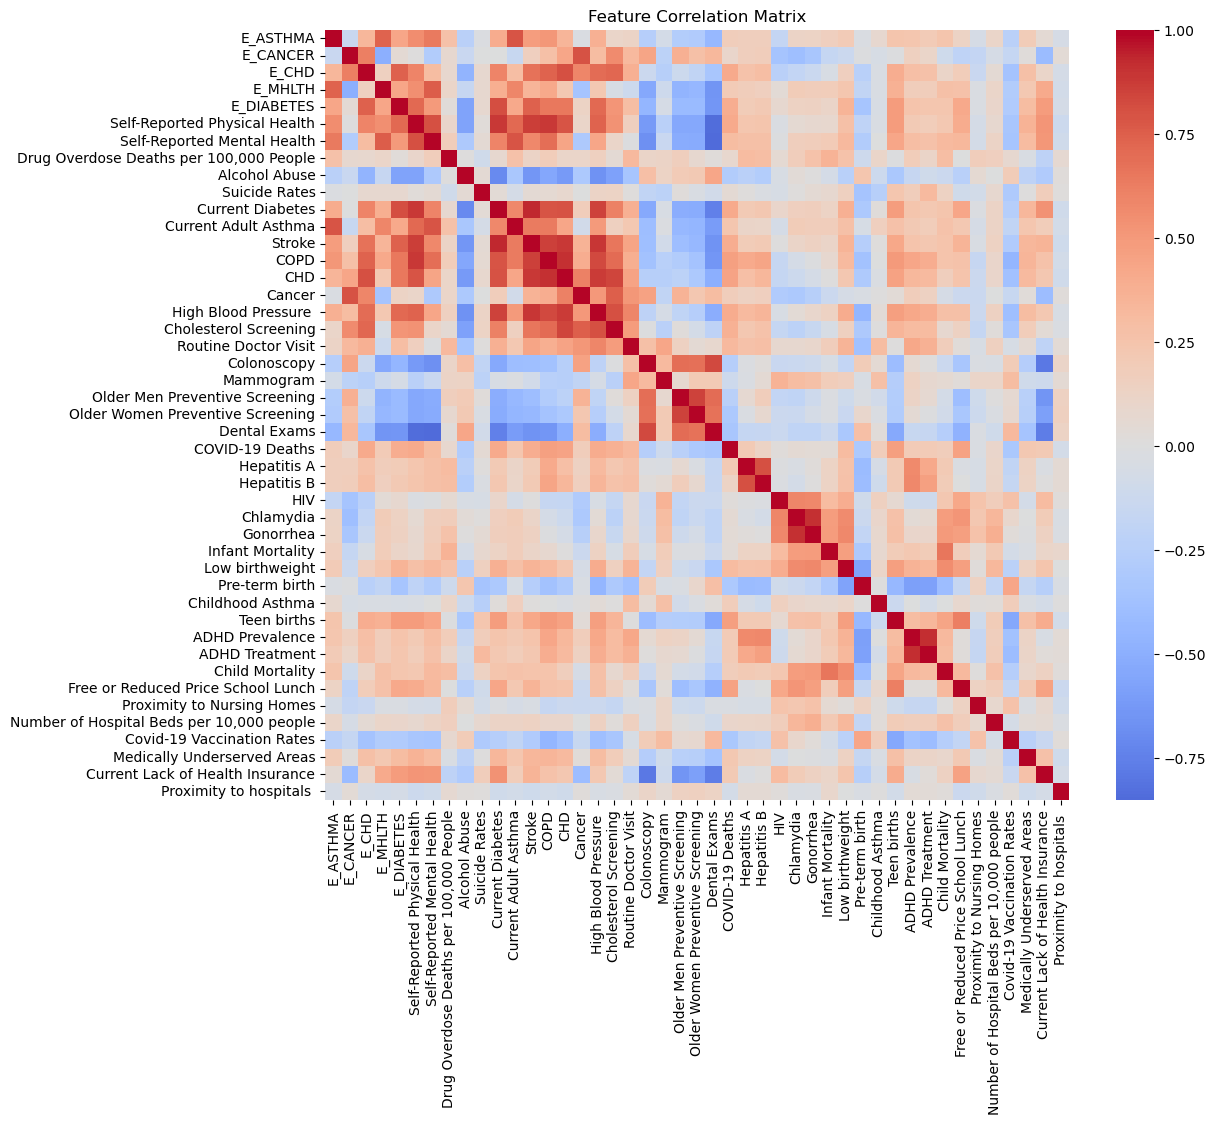

Highly correlated feature pairs (correlation > 0.7):
Current Diabetes                  Stroke                              0.931628
ADHD Prevalence                   ADHD Treatment                      0.917862
CHD                               COPD                                0.912906
Chlamydia                         Gonorrhea                           0.908248
High Blood Pressure               Stroke                              0.892427
CHD                               Stroke                              0.883426
Current Diabetes                  Self-Reported Physical Health       0.878539
COPD                              Self-Reported Physical Health       0.877915
CHD                               High Blood Pressure                 0.873132
Self-Reported Physical Health     Stroke                              0.867753
COPD                              Stroke                              0.857899
Current Diabetes                  High Blood Pressure                 0.852697

In [41]:
# correlation for Health domain vars
health_corr = corr_domain(X_health, threshold=0.7)

In [42]:
# final selection of Health domain predictors
# removing clear duplications between EJI and CVI, highly-correlated chronic conditions (eg: diabetes is a common comorbidity with COPD, cholesterol, etc. so keep diabetes only + the othe E_ chronic conditions), health screening vars (correlated with condition prevalence, insurance, healthcare access vars)
health_col_keep = ['E_CANCER','E_DIABETES','E_CHD', 'E_ASTHMA', 'E_MHLTH', 'Drug Overdose Deaths per 100,000 People', 'Alcohol Abuse', 'Suicide Rates', 'COVID-19 Deaths', 'HIV', 'Infant Mortality', 'Low birthweight', 'Pre-term birth', 'Teen births', 'ADHD Prevalence', 'Child Mortality', 'Free or Reduced Price School Lunch', 'Proximity to Nursing Homes', 'Number of Hospital Beds per 10,000 people', 'Covid-19 Vaccination Rates', 'Medically Underserved Areas', 'Current Lack of Health Insurance', 'Proximity to hospitals ']

## Socio Domain Corr

Correlation analysis for EJI domain [['SVM']] & CVI domain [['Baseline: Social & Economic', 'Baseline: Infrastructure']]
Selected columns: ['E_MINRTY', 'E_POV200', 'E_NOHSDP', 'E_UNEMP', 'E_RENTER', 'E_HOUBDN', 'E_UNINSUR', 'E_NOINT', 'E_AGE65', 'E_AGE17', 'E_DISABL', 'E_LIMENG', 'E_MOBILE', 'E_GROUPQ', 'Below Poverty', 'Unemployed', 'Low Income', 'No High School Diploma', 'Homicide Rate', 'Gun Violence', 'Religious Organizations', 'Civic and Social Organizations', 'Aged 65 or Older', 'Aged 17 or Younger', 'Civilian with a Disability', 'Single-Parent Households', 'Foster Children', 'Minority', 'Speaks English Less than Well', 'Undocumented Population', 'Hate Crimes', 'Prison Population', 'Redlining', 'Homeless Population', 'Veterans Population', 'Multi-Unit Structures', 'Mobile Homes', 'Crowding', 'No Vehicle', 'Group Quarters', 'Housing Foreclosure Risk', 'Percent of Housing Units Built Between 1940-1969 as of 2015-2019', 'Delay (congestion) per capita/census tract', 'Flooding risk to

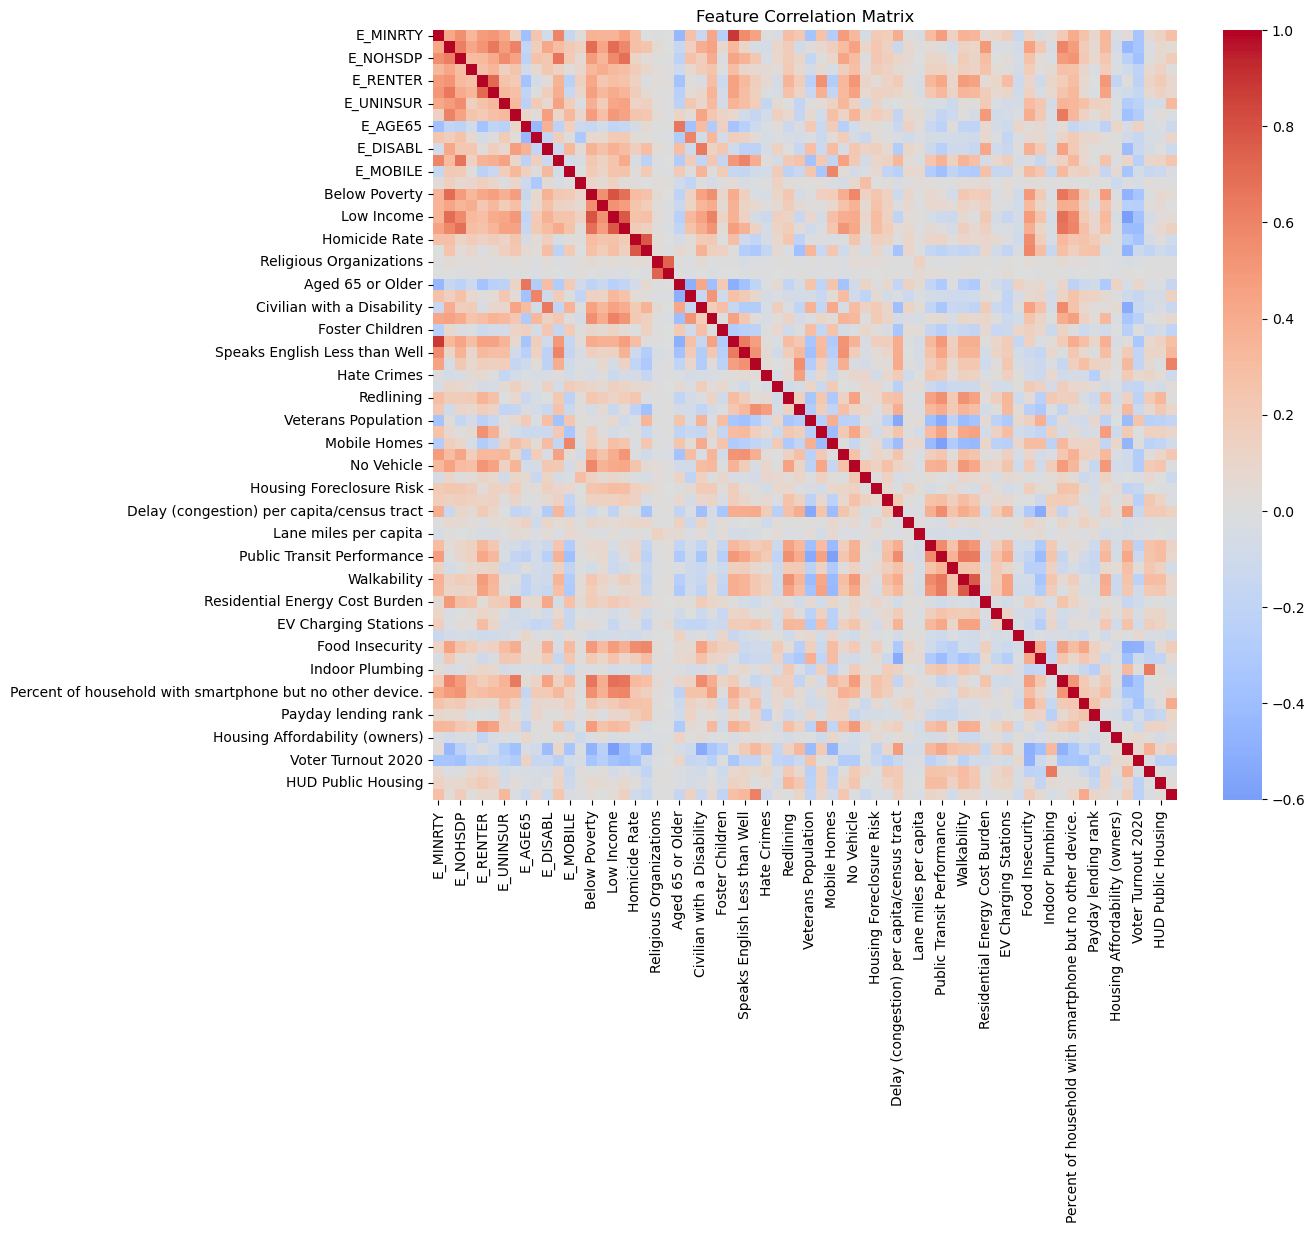

Highly correlated feature pairs (correlation > 0.7):
E_MINRTY                        Minority                   0.885051
Below Poverty                   Low Income                 0.792006
Gun Violence                    Homicide Rate              0.775454
Low Income                      No High School Diploma     0.774314
Bikability                      Walkability                0.765978
Civic and Social Organizations  Religious Organizations    0.731093
E_HOUBDN                        E_RENTER                   0.709757
dtype: float64


In [43]:
# correlation for Socioeconomic domain vars
socio_corr = corr_domain(X_socio, threshold=0.7)

In [44]:
# final selection of Socioeconomic domain predictors
# removing clear duplications between EJI and CVI, duplicate measures of income/poverty
socio_col_keep = ['E_MINRTY', 'E_POV200', 'E_NOHSDP', 'E_UNEMP', 'E_RENTER', 'E_HOUBDN', 'E_UNINSUR', 'E_NOINT', 'E_AGE65', 'E_AGE17', 'E_DISABL', 'E_LIMENG', 'E_MOBILE', 'E_GROUPQ', 'Below Poverty', 'Homicide Rate', 'Gun Violence', 'Religious Organizations', 'Civic and Social Organizations', 'Single-Parent Households', 'Foster Children', 'Undocumented Population', 'Hate Crimes', 'Prison Population', 'Redlining', 'Homeless Population', 'Veterans Population', 'Multi-Unit Structures', 'Mobile Homes', 'Crowding', 'No Vehicle', 'Housing Foreclosure Risk', 'Percent of Housing Units Built Between 1940-1969 as of 2015-2019', 'Delay (congestion) per capita/census tract', 'Flooding risk to roads', 'Lane miles per capita', 'Road Quality and Maintenance', 'Public Transit Performance', 'Bridge Quality and Maintenance', 'Walkability', 'Residential Energy Cost Burden', 'Share of energy from fossil fuels', 'EV Charging Stations', 'Modified Retail Food Environment Index', 'Food Insecurity', 'Access to Healthy Foods', 'Indoor Plumbing', 'Percent of Household with no internet access', 'Percent of household with smartphone but no other device.', 'Percent of Unbanked Households', 'Payday lending rank', 'Housing Affordability (renters)', 'Housing Affordability (owners)', 'Tax Base: Median Real Estate Taxes Paid', 'Voter Turnout 2020', 'Public Library Locations', 'HUD Public Housing', 'Aggregate funding amount for HUD grants']

## Envir Domain Corr

Correlation analysis for EJI domain [['EBM', 'CBM']] & CVI domain [['Baseline: Environment', 'Climate Change: Health', 'Climate Change: Social & Economic', 'Climate Change: Extreme Events']]
Selected columns: ['E_OZONE', 'E_PM', 'E_DSLPM', 'E_TOTCR', 'E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_COAL', 'E_LEAD', 'E_PARK', 'E_HOUAGE', 'E_WLKIND', 'E_RAIL', 'E_ROAD', 'E_AIRPRT', 'E_IMPWTR', 'E_NEHD', 'E_BURN', 'E_SMOKE', 'E_CFLD', 'E_DRGT', 'E_HRCN', 'E_RFLD', 'E_SWND', 'E_TRND', 'Total vehicle miles traveled per capita', 'Passenger vehicle miles traveled per capita', 'Truck vehicle miles traveled per capita', 'Heavy Duty Vehicle vehicle miles traveled per capita', 'Proximity to Ports', 'Rail Crossings', 'Traffic Proximity and Volume', 'National Transportation Noise Map', 'Risk-Screening Environmental Indicators (RSEI) ', 'Air Tox Respiratory', 'Air Tox Neurological', 'Air Tox Liver', 'Air Tox Developmental', 'Air Tox Reproductive', 'Air Tox Kidney', 'Air Tox Immunological', 'Air Tox Thyroid', 

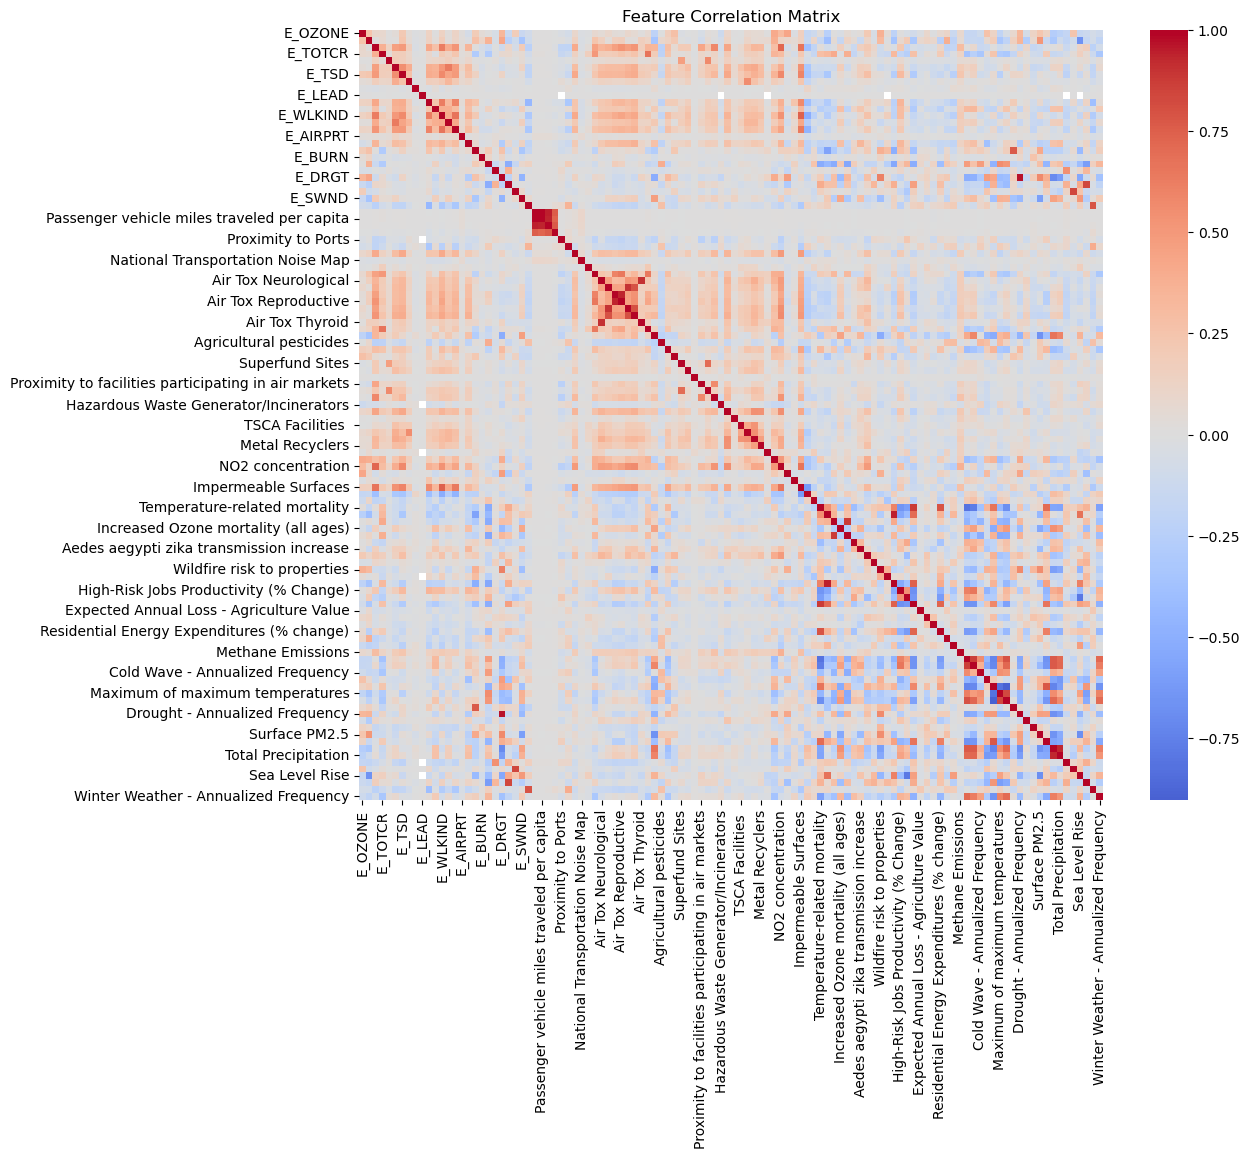

Highly correlated feature pairs (correlation > 0.8):
Passenger vehicle miles traveled per capita   Total vehicle miles traveled per capita       0.999082
Drought - Annualized Frequency                E_DRGT                                        0.964562
Total vehicle miles traveled per capita       Truck vehicle miles traveled per capita       0.946222
Cost of climate disasters                     Deaths from climate disasters                 0.941061
Air Tox Developmental                         Air Tox Reproductive                          0.939814
Passenger vehicle miles traveled per capita   Truck vehicle miles traveled per capita       0.938505
Standardized Precip Index                     Total Precipitation                           0.925822
Air Tox Neurological                          Air Tox Thyroid                               0.910112
Air Tox Kidney                                Air Tox Liver                                 0.902623
Frost Days                            

In [45]:
# correlation for Environment domain vars
env_corr = corr_domain(X_env)

In [46]:
# final selection of Environment domain predictors
# removing clear duplication between EJI and CVI, duplicate measures of temperature
env_col_keep = ['E_OZONE', 'E_PM', 'E_DSLPM', 'E_TOTCR', 'E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_COAL', 'E_LEAD', 'E_PARK', 'E_HOUAGE', 'E_WLKIND', 'E_RAIL', 'E_ROAD', 'E_AIRPRT', 'E_IMPWTR', 'E_NEHD', 'E_BURN', 'E_SMOKE', 'E_CFLD', 'E_DRGT', 'E_HRCN', 'E_RFLD', 'E_SWND', 'E_TRND', 'Total vehicle miles traveled per capita', 'Proximity to Ports', 'Rail Crossings', 'Traffic Proximity and Volume', 'National Transportation Noise Map', 'Risk-Screening Environmental Indicators (RSEI) ', 'Air Tox Respiratory', 'Air Tox Neurological', 'Air Tox Liver', 'Air Tox Developmental', 'Air Tox Reproductive', 'Air Tox Kidney', 'Air Tox Immunological', 'Air Tox Thyroid', 'Air Tox Total Cancer Risk', 'Black Carbon', 'Agricultural pesticides', 'Lead in drinking water violations', 'Superfund Sites', 'Brownfields', 'Stream Toxicity Risk-Screening Environmental Indicators (RSEI)', 'Proximity to facilities participating in air markets', 'NPL sites', 'Hazardous Waste Management Facilities (TSDFs) ', 'Hazardous Waste Generator/Incinerators', 'Facilities with Enforcement or Violation', 'Landfills', 'TSCA Facilities ', 'Risk Management Plan Facilities', 'Chemical Manufacturers', 'Metal Recyclers', 'Active Oil and Gas Wells', 'Annual average PM2.5 concentrations', 'NO2 concentration', 'Impermeable Surfaces', 'Forest Land Cover', 'Native American Lands', 'Temperature-related mortality', 'Deaths from climate disasters', 'Increased PM2.5 mortality - CVD (ages 65+)', 'Increased Ozone mortality (all ages)', 'Increase in childhood asthma incidence', 'Aedes aegypti dengue transmission increase', 'Aedes aegypti zika transmission increase', 'FEMA Hazard Mitigation Grants ', 'Flooding risk to properties', 'Wildfire risk to properties', 'Property taxes expected to be lost by 2045 due to chronic inundation ', 'Cost of climate disasters', 'High-Risk Jobs Productivity (% Change)', 'Yields (% change)', 'Outdoor workers - work days at risk per year', 'Expected Annual Loss - Agriculture Value', 'Expected Annual Loss - Building Value', 'Expected Annual Loss - Population Equivalence ', 'Residential Energy Expenditures (% change)', 'Share of Jobs in Agriculture', 'State energy-related carbon dioxide emissions by year', 'Methane Emissions', 'Property Crimes (% change)', 'Violent Crimes (% change)', 'Cold Wave - Annualized Frequency', 'Days with maximum temperature above 40C', 'Maximum of maximum temperatures', 'Mean temperature', 'Urban Heat Island Extreme Heat Days', 'Consecutive Dry Days', 'Surface PM2.5', 'Snowfall', 'Standardized Precip Index']

In [47]:
# function to calculate GEI domain score from model estimation of outcome + comparison with EJI/CVI
def calc_index_score(y, ypred, eji_dom_score, cvi_dom_score):
    # higher score indicates higher vulnerability
    gei_score = pd.Series(ypred).rank(pct=True, ascending=False)
    y_true_pctl = pd.Series(y).rank(pct=True, ascending=False)
    gei_score.name = 'gei_score'
    y.name = 'y_true'

    # print first 5 obs of ytrue, ypred, GEI/EJI/CVI scores - lower ypred (life expectancy) should have higher GEI score
    print(pd.concat([y, pd.Series(ypred, name='y_pred'), gei_score, eji_dom_score, eji_index_score, cvi_dom_score, cvi_index_score], axis=1).head())

    # pearson's correlation between ytrue and indices
    corr_gei_eji = gei_score.corr(eji_dom_score)
    corr_gei_cvi = gei_score.corr(cvi_dom_score)
    corr_gei_y = gei_score.corr(y_true_pctl)
    corr_eji_y = eji_dom_score.corr(y_true_pctl)
    corr_cvi_y = cvi_dom_score.corr(y_true_pctl)

    print(f"Correlation between GEI domain index and EJI domain index: {corr_gei_eji:.4f}")
    print(f"Correlation between GEI domain index and CVI domain index: {corr_gei_cvi:.4f}")
    print(f"Correlation between GEI domain index and y_true: {corr_gei_y:.4f}")
    print(f"Correlation between EJI domain index and y_true: {corr_eji_y:.4f}")
    print(f"Correlation between CVI domain index and y_true: {corr_cvi_y:.4f}")

    # simple linear regression of indices on ytrue
    def get_r2(x, y):
        reg = LinearRegression()
        i = x.dropna().index.to_list()
        x1, y1 = x[i].to_frame(), y[i]
        r2 = reg.fit(x1, y1).score(x1, y1)
        return r2

    r2_gei = get_r2(gei_score, y)
    r2_eji = get_r2(eji_dom_score, y)
    r2_cvi = get_r2(cvi_dom_score, y)

    print(f"GEI R-squared on predicting y_true: {r2_gei:.4f}")
    print(f"EJI R-squared on predicting y_true: {r2_eji:.4f}")
    print(f"CVI R-squared on predicting y_true: {r2_cvi:.4f}")

    return gei_score, [corr_gei_eji, corr_gei_cvi, corr_gei_y, corr_eji_y, corr_cvi_y], [r2_gei, r2_eji, r2_cvi]

# LASSO Regression

In [48]:
# run LASSO feature selection with 5-fold CV
def lasso_feature_selection(x, y, domain_name):

    lasso = LassoCV(cv=5, random_state=42, max_iter=10000)

    print(f"LASSO feature selection for domain: {domain_name}")
    xscaled = StandardScaler().fit_transform(x)
    lasso.fit(xscaled, y)

    ypred = lasso.predict(xscaled)
    mse = mean_squared_error(y, ypred)
    print(f"LASSO Mean Squared Error: {mse:.4f}")

    rsquared = lasso.score(xscaled, y)
    print(f"LASSO R-squared: {rsquared:.4f}")
    
    coef = pd.Series(lasso.coef_, index=x.columns)
    print("LASSO Coefficients:")
    print(coef)
    
    selected_features = coef[coef != 0].index.tolist()
    print("Number of original features:", x.shape[1])
    print(f"Selected features ({len(selected_features)}): {selected_features}")
    return ypred, selected_features
    

## Health LASSO

In [49]:
# lasso can't work with missing values so drop missing rows
i = X_health[health_col_keep].dropna().index
X_health_clean = X_health[health_col_keep].dropna().reset_index(drop=True)
Y_health_clean = Y[i].reset_index(drop=True)

Y_health_pred, X_health_selected = lasso_feature_selection(X_health_clean, Y_health_clean, "Health")
health_gei_score_lasso, health_corr_lasso, heatlh_r2_lasso = calc_index_score(Y_health_clean, Y_health_pred, eji_health_score[i].reset_index(drop=True), cvi_health_score[i].reset_index(drop=True))

LASSO feature selection for domain: Health
LASSO Mean Squared Error: 6.5797
LASSO R-squared: 0.4613
LASSO Coefficients:
E_CANCER                                     0.000000
E_DIABETES                                  -0.250241
E_CHD                                       -0.000000
E_ASTHMA                                    -0.923870
E_MHLTH                                     -0.277923
Drug Overdose Deaths per 100,000 People     -0.314590
Alcohol Abuse                                0.068492
Suicide Rates                               -0.000000
COVID-19 Deaths                             -0.000000
HIV                                          0.000000
Infant Mortality                            -0.050903
Low birthweight                             -0.231284
Pre-term birth                               0.238495
Teen births                                 -0.128286
ADHD Prevalence                             -0.178642
Child Mortality                             -0.128108
Free or Reduced 

## Socio LASSO

In [50]:
# lasso can't work with missing values so drop missing rows
i = X_socio[socio_col_keep].dropna().index
X_socio_clean = X_socio[socio_col_keep].dropna().reset_index(drop=True)
Y_socio_clean = Y[i].dropna().reset_index(drop=True)

Y_socio_pred, X_socio_selected = lasso_feature_selection(X_socio_clean, Y_socio_clean, "Socio")
socio_gei_score_lasso, socio_corr_lasso, socio_r2_lasso = calc_index_score(Y_socio_clean, Y_socio_pred, eji_socio_score[i].reset_index(drop=True), cvi_socio_score[i].reset_index(drop=True))

LASSO feature selection for domain: Socio
LASSO Mean Squared Error: 5.5126
LASSO R-squared: 0.5755
LASSO Coefficients:
E_MINRTY                                                            0.000000
E_POV200                                                           -0.161981
E_NOHSDP                                                           -0.111546
E_UNEMP                                                            -0.051202
E_RENTER                                                           -0.061033
E_HOUBDN                                                           -0.000000
E_UNINSUR                                                          -0.000000
E_NOINT                                                            -0.000000
E_AGE65                                                             0.206148
E_AGE17                                                            -0.000000
E_DISABL                                                           -0.280322
E_LIMENG                          

## Envir LASSO

In [51]:
# lasso can't work with missing values so drop missing rows
env_col_keep_lasso = ['E_OZONE', 'E_PM', 'E_DSLPM', 'E_TOTCR', 'E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_COAL', 'E_LEAD', 'E_PARK', 'E_HOUAGE', 'E_WLKIND', 'E_RAIL', 'E_ROAD', 'E_AIRPRT', 'E_IMPWTR', 'E_NEHD', 'E_BURN', 'E_SMOKE', 'E_CFLD', 'E_DRGT', 'E_HRCN', 'E_RFLD', 'E_SWND', 'E_TRND']
i = X_env[env_col_keep_lasso].dropna().index
X_env_clean = X_env[env_col_keep_lasso].dropna().reset_index(drop=True)
Y_env_clean = Y[i].dropna().reset_index(drop=True)

Y_env_pred, X_env_selected = lasso_feature_selection(X_env_clean, Y_env_clean, "Env")
env_gei_score_lasso, env_corr_lasso, env_r2_lasso = calc_index_score(Y_env_clean, Y_env_pred, eji_env_score[i].reset_index(drop=True), cvi_env_score[i].reset_index(drop=True))

# lasso doesn't work here because there are no rows with complete data
# print(X_env_clean.shape)

LASSO feature selection for domain: Env
LASSO Mean Squared Error: 10.4694
LASSO R-squared: 0.1664
LASSO Coefficients:
E_OZONE    -0.014974
E_PM        0.047239
E_DSLPM     0.418232
E_TOTCR    -0.248633
E_NPL       0.000000
E_TRI      -0.453104
E_TSD       0.430336
E_RMP      -0.221183
E_COAL     -0.061131
E_LEAD      0.000000
E_PARK      0.326544
E_HOUAGE   -0.382529
E_WLKIND    0.000000
E_RAIL     -0.381413
E_ROAD      0.000000
E_AIRPRT   -0.000000
E_IMPWTR    0.038366
E_NEHD      0.647321
E_BURN      0.000000
E_SMOKE     0.178798
E_CFLD      0.000000
E_DRGT     -0.000000
E_HRCN      0.024555
E_RFLD      0.013583
E_SWND      0.030760
E_TRND      0.000000
dtype: float64
Number of original features: 26
Selected features (17): ['E_OZONE', 'E_PM', 'E_DSLPM', 'E_TOTCR', 'E_TRI', 'E_TSD', 'E_RMP', 'E_COAL', 'E_PARK', 'E_HOUAGE', 'E_RAIL', 'E_IMPWTR', 'E_NEHD', 'E_SMOKE', 'E_HRCN', 'E_RFLD', 'E_SWND']
   y_true     y_pred  gei_score         0  RPL_EJI_CBM         1  \
0    73.1  76.349613   

# Random Forest

In [ ]:
# random forest with grid search
def rf(x, y, domain):
    print(f"Random Forest Regression for domain: {domain}")
    rfg = RandomForestRegressor(random_state=14, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None]
        # 'min_samples_split': [2, 5],
        # 'min_samples_leaf': [1, 2, 4]
    }

    # use 3-fold CV instead of 5 and ramdom search instead of grid search to reduce runtime
    grid_search = GridSearchCV(estimator=rfg, param_grid=param_grid, cv=3, n_jobs=-1)
    # grid_search = RandomizedSearchCV(estimator=rfg, param_distributions=param_grid, n_iter=6, cv=3, n_jobs=-1, random_state=42)
    grid_search.fit(x, y)
    print("Best RF parameters: ", grid_search.best_params_)
    print("Best mean squared error: ", grid_search.best_score_)

    model = grid_search.best_estimator_
    model.fit(x,y)
    
    ypred = model.predict(x)
    mse = mean_squared_error(y, ypred)
    print(f"Random Forest Mean Squared Error: {mse:.4f}")
    rsquared = model.score(x, y)
    print(f"Random Forest R-squared: {rsquared:.4f}")
    
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    print(feature_importance_df)

    return ypred, feature_importance_df

## Health RF

In [53]:
X_health_clean = X_health[health_col_keep]
Y_health_pred, X_health_importance = rf(X_health_clean, Y, "Health")
health_gei_score_rf, health_corr_rf, health_r2_rf = calc_index_score(Y, Y_health_pred, eji_health_score, cvi_health_score)

Random Forest Regression for domain: Health
Best RF parameters:  {'max_depth': 20, 'n_estimators': 300}
Best mean squared error:  0.48614898849795
Random Forest Mean Squared Error: 1.0930
Random Forest R-squared: 0.9131
                                      Feature  Importance
4                                     E_MHLTH    0.279860
21           Current Lack of Health Insurance    0.107214
6                               Alcohol Abuse    0.103103
19                 Covid-19 Vaccination Rates    0.056846
17                 Proximity to Nursing Homes    0.051973
3                                    E_ASTHMA    0.049978
22                    Proximity to hospitals     0.035610
15                            Child Mortality    0.035006
1                                  E_DIABETES    0.032909
5     Drug Overdose Deaths per 100,000 People    0.031198
13                                Teen births    0.030012
0                                    E_CANCER    0.023222
2                         

In [ ]:
# plot top 10 feature importance for each domain for random forest
def plot_feature_importance(feature_importance_df, domain):
    # Sort data and get top 10
    sort_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)
    sort_df = sort_df.sort_values(by='Importance', ascending=True)  # Reverse for plotting
    
    # Create figure with better styling (smaller height for 10 bars)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create gradient colors based on importance values
    colors = plt.cm.RdPu(sort_df['Importance'] / sort_df['Importance'].max())
    
    # Create horizontal bar chart with smaller bar height
    bars = ax.barh(sort_df['Feature'], sort_df['Importance'], 
                   height=0.6, color=colors, edgecolor='white', linewidth=1.2)
    
    # Customize title and labels
    ax.set_title(f'Top 10 Feature Importance: {domain} Domain', 
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Importance Score', fontsize=12, fontweight='semibold')
    # ax.set_ylabel('Features', fontsize=12, fontweight='semibold')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, sort_df['Importance'])):
        ax.text(value, bar.get_y() + bar.get_height()/2, 
                f' {value:.4f}', 
                va='center', fontsize=9, color='black', fontweight='medium')
    
    # Customize grid
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # Adjust tick parameters
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Add a subtle background color
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')
    
    plt.tight_layout()
    plt.savefig(f'../Output/rf_feature_importance_{domain.lower()}.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

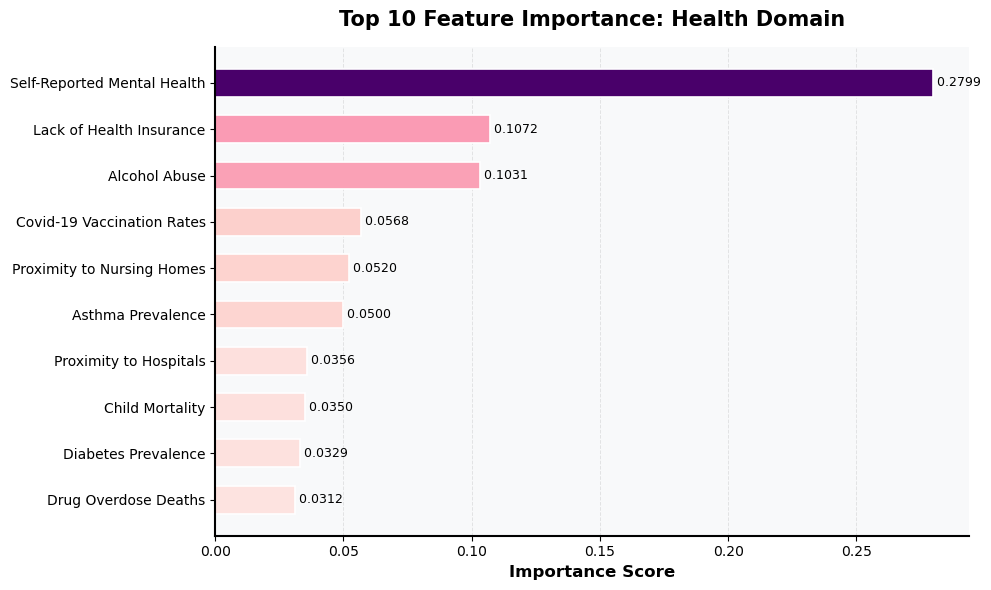

In [ ]:
# Rename features for better readability in the plot
X_health_importance_renamed = X_health_importance.copy()
rename_dict = {
    'E_MHLTH': 'Self-Reported Mental Health',
    'E_ASTHMA': 'Asthma Prevalence',
    'E_DIABETES': 'Diabetes Prevalence',
    'Current Lack of Health Insurance': 'Lack of Health Insurance',
    'Proximity to hospitals ': 'Proximity to Hospitals',
    'Drug Overdose Deaths per 100,000 People': 'Drug Overdose Deaths'}
X_health_importance_renamed['Feature'] = X_health_importance_renamed['Feature'].replace(rename_dict)

plot_feature_importance(X_health_importance_renamed, "Health")

## Socio RF

In [54]:
X_socio_clean = X_socio[socio_col_keep]
Y_socio_pred, X_socio_importance = rf(X_socio_clean, Y, "Socio")
socio_gei_score_rf, socio_corr_rf, socio_r2_rf = calc_index_score(Y, Y_socio_pred, eji_socio_score, cvi_socio_score)

Random Forest Regression for domain: Socio
Best RF parameters:  {'max_depth': None, 'n_estimators': 300}
Best mean squared error:  0.5323958486332893
Random Forest Mean Squared Error: 0.6338
Random Forest R-squared: 0.9496
                                              Feature  Importance
53            Tax Base: Median Real Estate Taxes Paid    0.235575
14                                      Below Poverty    0.166253
30                                         No Vehicle    0.049511
47       Percent of Household with no internet access    0.027052
16                                       Gun Violence    0.026331
25                                Homeless Population    0.025665
19                           Single-Parent Households    0.025560
40                     Residential Energy Cost Burden    0.023339
17                            Religious Organizations    0.018505
32  Percent of Housing Units Built Between 1940-19...    0.017903
31                           Housing Foreclosure Ri

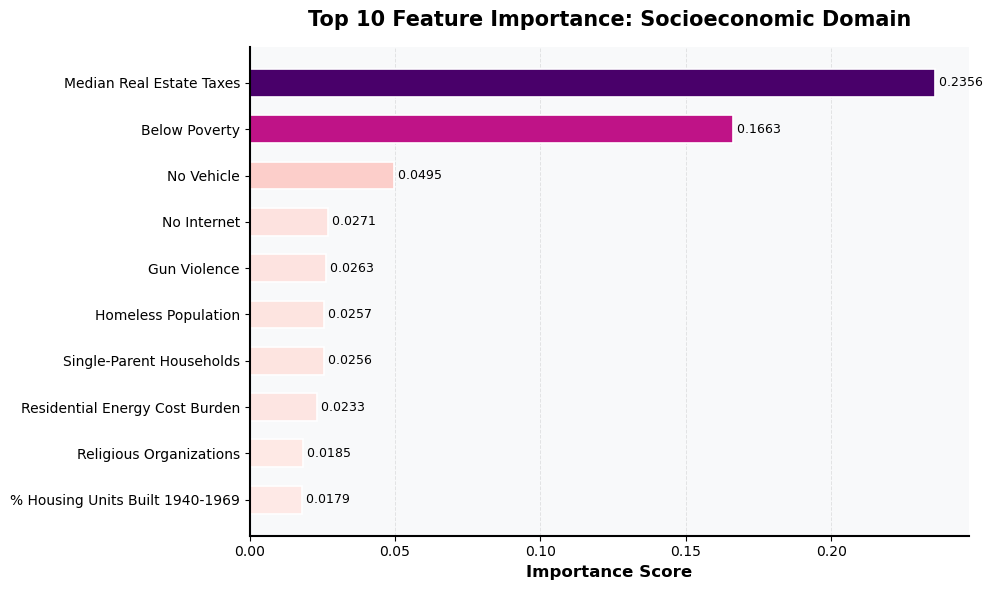

In [130]:
# rename features for better readability in the plot
X_socio_importance_renamed = X_socio_importance.copy()
rename_dict = {
    'Tax Base: Median Real Estate Taxes Paid': 'Median Real Estate Taxes',
    'Percent of Household with no internet access': 'No Internet',
    'Percent of Housing Units Built Between 1940-1969 as of 2015-2019': '% Housing Units Built 1940-1969'}
X_socio_importance_renamed['Feature'] = X_socio_importance_renamed['Feature'].replace(rename_dict)

plot_feature_importance(X_socio_importance_renamed, "Socioeconomic")

## Envir RF

In [127]:
X_env_clean = X_env[env_col_keep]
Y_env_pred, X_env_importance = rf(X_env_clean, Y, "Env")
env_gei_score_rf, env_corr_rf, env_r2_rf = calc_index_score(Y, Y_env_pred, eji_env_score, cvi_env_score)

Random Forest Regression for domain: Env
Best RF parameters:  {'max_depth': None, 'n_estimators': 300}
Best mean squared error:  0.13938706193340636
Random Forest Mean Squared Error: 0.7449
Random Forest R-squared: 0.9408
                                              Feature  Importance
64                      Deaths from climate disasters    0.113117
45                                        Brownfields    0.078262
65         Increased PM2.5 mortality - CVD (ages 65+)    0.057203
11                                           E_HOUAGE    0.039650
60                               Impermeable Surfaces    0.033072
54                    Risk Management Plan Facilities    0.021206
56                                    Metal Recyclers    0.019905
79              Expected Annual Loss - Building Value    0.019802
29                       Traffic Proximity and Volume    0.017128
55                             Chemical Manufacturers    0.017067
51           Facilities with Enforcement or Violatio

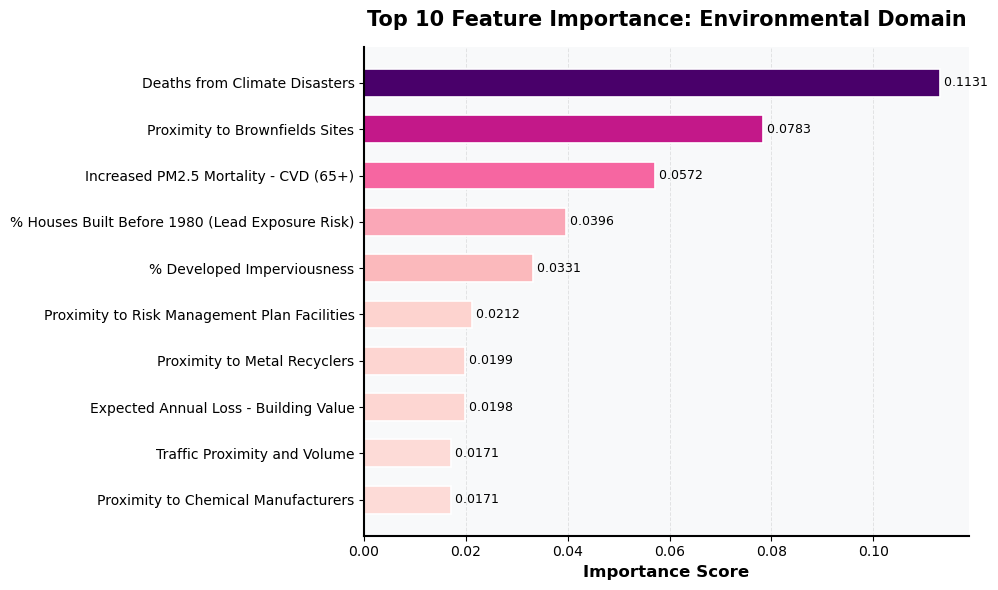

In [132]:
# rename features for better readability in the plot
X_env_importance_renamed = X_env_importance.copy()
rename_dict = {
    'Deaths from climate disasters': 'Deaths from Climate Disasters',
    'Brownfields': 'Proximity to Brownfields Sites',
    'Increased PM2.5 mortality - CVD (ages 65+)': 'Increased PM2.5 Mortality - CVD (65+)',
    'E_HOUAGE': '% Houses Built Before 1980 (Lead Exposure Risk)',
    'Impermeable Surfaces': '% Developed Imperviousness',
    'Risk Management Plan Facilities': 'Proximity to Risk Management Plan Facilities',
    'Metal Recyclers': 'Proximity to Metal Recyclers',
    # 'Expected Annual Loss - Building Value': 'Expected Annual Loss - Building Value',
    'Chemical Manufacturers': 'Proximity to Chemical Manufacturers'
}
X_env_importance_renamed['Feature'] = X_env_importance_renamed['Feature'].replace(rename_dict)

plot_feature_importance(X_env_importance_renamed, "Environmental")

# Geo Index Score

In [134]:
# calculate overall GEI score
def calc_gei_overall(domain_scores):
    sum = pd.concat(domain_scores, axis=1).sum(axis=1)
    gei_score = pd.Series(sum).rank(pct=True)
    gei_score.name = 'gei_index'

    y_true_pctl = pd.Series(Y).rank(pct=True, ascending=False)

    # pearson's correlation between ytrue and indices
    corr_gei_eji = gei_score.corr(eji_index_score)
    corr_gei_cvi = gei_score.corr(cvi_index_score)
    corr_gei_y = gei_score.corr(y_true_pctl)
    corr_eji_y = eji_index_score.corr(y_true_pctl)
    corr_cvi_y = cvi_index_score.corr(y_true_pctl)

    print(f"Correlation of GEI overall index with EJI overall index: {corr_gei_eji:.4f}")
    print(f"Correlation of GEI overall index with CVI overall index: {corr_gei_cvi:.4f}")
    print(f"Correlation of GEI overall index with y_true: {corr_gei_y:.4f}")
    print(f"Correlation of EJI overall index with y_true: {corr_eji_y:.4f}")
    print(f"Correlation of CVI overall index with y_true: {corr_cvi_y:.4f}")

    # simple linear regression of indices on ytrue
    def get_r2(x, y):
        reg = LinearRegression()
        i = x.dropna().index.to_list()
        x1, y1 = x[i].to_frame(), y[i]
        r2 = reg.fit(x1, y1).score(x1, y1)
        return r2

    r2_gei = get_r2(gei_score, Y)
    r2_eji = get_r2(eji_index_score, Y)
    r2_cvi = get_r2(cvi_index_score, Y)

    print(f"GEI R-squared on predicting y_true: {r2_gei:.4f}")
    print(f"EJI R-squared on predicting y_true: {r2_eji:.4f}")
    print(f"CVI R-squared on predicting y_true: {r2_cvi:.4f}")
    
    return gei_score, [corr_gei_eji, corr_gei_cvi, corr_gei_y, corr_eji_y, corr_cvi_y], [r2_gei, r2_eji, r2_cvi]

In [135]:
gei_all_rf, corr_all_rf, r2_all_rf = calc_gei_overall([health_gei_score_rf, socio_gei_score_rf, env_gei_score_rf])

Correlation of GEI overall index with EJI overall index: 0.4496
Correlation of GEI overall index with CVI overall index: 0.7227
Correlation of GEI overall index with y_true: 0.9779
Correlation of EJI overall index with y_true: 0.4052
Correlation of CVI overall index with y_true: 0.6536
GEI R-squared on predicting y_true: 0.8819
EJI R-squared on predicting y_true: 0.1662
CVI R-squared on predicting y_true: 0.3977


In [136]:
# print comparison table for best RF model vs EJI/CVI

rf_corrs = np.vstack([
    health_corr_rf,
    socio_corr_rf,
    env_corr_rf,
    corr_all_rf
])

rf_r2 = np.vstack([
    health_r2_rf,
    socio_r2_rf,
    env_r2_rf,
    r2_all_rf
])

all_stats = np.hstack([rf_corrs, rf_r2])

result = pd.DataFrame(
    all_stats,
    columns=['Corr(GEI, EJI)', 'Corr(GEI, CVI)', 'Corr(GEI, y_true)', 'Corr(EJI, y_true)', 'Corr(CVI, y_true)', 'GEI R2', 'EJI R2', 'CVI R2'],
    index=['Health', 'Socio', 'Env', 'Overall']
)
print(result.round(2))

         Corr(GEI, EJI)  Corr(GEI, CVI)  Corr(GEI, y_true)  Corr(EJI, y_true)  \
Health             0.53            0.85               0.96               0.46   
Socio              0.50            0.67               0.98               0.45   
Env               -0.02            0.27               0.98              -0.01   
Overall            0.45            0.72               0.98               0.41   

         Corr(CVI, y_true)  GEI R2  EJI R2  CVI R2  
Health                0.77    0.85    0.21    0.56  
Socio                 0.60    0.89    0.20    0.34  
Env                   0.23    0.88    0.00    0.05  
Overall               0.65    0.88    0.17    0.40  


# Output

In [137]:
### get state and county names for all census tracts in final dataset

# get names from EJI data
eji_names = eji_data_raw[['GEOID','COUNTY','StateDesc','STATEABBR']]

# get names from CVI data
cvi_names = cvi_data_raw[['FIPS Code','State','County']]

# combine
all_names = eji_names.merge(cvi_names, left_on='GEOID', right_on='FIPS Code', how='outer')
all_names['Tract FIPS'] = all_names['GEOID'].combine_first(all_names['FIPS Code'])
all_names['Census Tract'] = all_names['Tract FIPS'].str[5:]
all_names['County'] = all_names['COUNTY'].combine_first(all_names['County']).str.replace(' County','')
all_names['State'] = all_names['STATEABBR'].combine_first(all_names['State'])

# fill missing state description and print to check
all_names = all_names.sort_values(by=['State','StateDesc'], na_position='last').ffill()
print(all_names[['State','StateDesc']].drop_duplicates())

all_names = all_names[['Tract FIPS','Census Tract','County','State','StateDesc']]


      State                                     StateDesc
1682     AK                                        Alaska
0        AL                                       Alabama
3882     AR                                      Arkansas
96619    AS                                American Samoa
1879     AZ                                       Arizona
4844     CA                                    California
15149    CO                                      Colorado
17615    CT                                   Connecticut
18796    DC                          District of Columbia
18494    DE                                      Delaware
19027    FL                                       Florida
25093    GA                                       Georgia
96637    GU                                          Guam
28598    HI                                        Hawaii
35039    IA                                          Iowa
29180    ID                                         Idaho
29740    IL   

In [138]:
# get top 10 features of each domain -- output as a dataset with rank + var labels
def top10(domain_importance, domain_name):
    top10 = domain_importance.sort_values(by='Importance', ascending=False)[:10]
    top10['Domain'] = domain_name
    top10['Rank'] = top10['Importance'].rank(ascending=False)
    top10 = top10.merge(eji_dict[['2024 VARIABLE NAME','2024 VARIABLE DESCRIPTION']], how='left', left_on='Feature', right_on='2024 VARIABLE NAME')
    top10 = top10.merge(cvi_dict[['Indicator','Indicator Unit']], how='left', left_on='Feature', right_on='Indicator')
    top10['Label'] = top10['2024 VARIABLE DESCRIPTION'].combine_first(top10['Indicator Unit'])
    top10 = top10[['Feature','Label','Domain','Rank']]

    return top10

top10_health = top10(X_health_importance, 'Health')
top10_socio = top10(X_socio_importance, 'Socioeconomic')
top10_env = top10(X_env_importance, 'Environment')

top10_features_df = pd.concat([top10_health, top10_socio, top10_env], axis=0)
top10_features_df



,Feature,Label,Domain,Rank
0,E_MHLTH,Percentage of individuals reporting not good m...,Health,1.0
1,Current Lack of Health Insurance,Age-adjusted prevalence of adults 18–64 years ...,Health,2.0
2,Alcohol Abuse,Age-adjusted prevalence of adults who report ...,Health,3.0
3,Covid-19 Vaccination Rates,Percentage of people who are fully COVID-19 va...,Health,4.0
4,Proximity to Nursing Homes,Proximity to nursing homes (5km centroid radi...,Health,5.0
5,E_ASTHMA,Percentage of individuals with asthma,Health,6.0
6,Proximity to hospitals,"Proximity to hospitals (5km centroid radius),...",Health,7.0
7,Child Mortality,Number of deaths among residents under age 18 ...,Health,8.0
8,E_DIABETES,Percentage of individuals with diabetes,Health,9.0
9,"Drug Overdose Deaths per 100,000 People","Number of drug poisoning deaths per 100,000 po...",Health,10.0


In [139]:
from datetime import date
today = date.today()
top10_features_df.to_csv(f'../Output/GEI_top10_features_{today}.csv', index=False)

In [140]:
### output index scores and top 10 features of each domain to CSV ###
# get GEI overall and domain scores
gei_scores = pd.concat([eji_cvi_df['Tract FIPS'], gei_all_rf, health_gei_score_rf, socio_gei_score_rf, env_gei_score_rf], axis=1, keys=['Tract FIPS', 'GEI_overall_score', 'GEI_health_score', 'GEI_socio_score', 'GEI_env_score']).reset_index(drop=True)

# get top 10 features of each domain
top10_features = top10_features_df['Feature'].to_list()
keepvars = top10_features + ['Tract FIPS']

# merge top 10 features and GEI scores
output_df = eji_cvi_df[keepvars].merge(gei_scores, on='Tract FIPS', how='inner')

# calculate percentile rank for each feature
for col in top10_features:
    output_df[f"pctl_{col}"] = output_df[col].rank(pct=True)

# add state/county name
output_df = output_df.merge(all_names, on='Tract FIPS', how='left').rename(columns={'Tract FIPS':'GEOID'})
       
output_df.head()

,E_MHLTH,Current Lack of Health Insurance,Alcohol Abuse,Covid-19 Vaccination Rates,Proximity to Nursing Homes,E_ASTHMA,Proximity to hospitals,Child Mortality,E_DIABETES,"Drug Overdose Deaths per 100,000 People",...,pctl_Impermeable Surfaces,pctl_Risk Management Plan Facilities,pctl_Metal Recyclers,pctl_Expected Annual Loss - Building Value,pctl_Traffic Proximity and Volume,pctl_Chemical Manufacturers,Census Tract,County,State,StateDesc
0,20.0,12.3,14.4,44.1,0.917108,11.0,4.81,56.667926,13.8,8.384539,...,0.226746,0.117823,0.053905,0.273789,0.183234,0.241069,020100,Autauga,AL,Alabama
1,19.0,18.2,12.5,44.1,1.926729,10.7,2.72,56.667926,14.7,8.384539,...,0.399089,0.123090,0.004730,0.291084,0.320439,0.410616,020200,Autauga,AL,Alabama
2,19.7,14.6,13.9,44.1,2.921713,11.0,1.75,56.667926,14.1,8.384539,...,0.376594,0.128691,0.051638,0.281282,0.554068,0.500216,020300,Autauga,AL,Alabama
3,17.8,11.1,13.8,44.1,3.721395,10.1,1.43,56.667926,13.4,8.384539,...,0.383878,0.136330,0.056148,0.398761,0.715274,0.527892,020400,Autauga,AL,Alabama
4,18.7,11.4,14.7,44.1,2.634372,10.1,2.72,56.667926,13.4,8.384539,...,0.525628,0.164368,0.113521,0.686574,0.412812,0.480609,020500,Autauga,AL,Alabama


In [141]:
output_df.describe()

,E_MHLTH,Current Lack of Health Insurance,Alcohol Abuse,Covid-19 Vaccination Rates,Proximity to Nursing Homes,E_ASTHMA,Proximity to hospitals,Child Mortality,E_DIABETES,"Drug Overdose Deaths per 100,000 People",...,pctl_Deaths from climate disasters,pctl_Brownfields,pctl_Increased PM2.5 mortality - CVD (ages 65+),pctl_E_HOUAGE,pctl_Impermeable Surfaces,pctl_Risk Management Plan Facilities,pctl_Metal Recyclers,pctl_Expected Annual Loss - Building Value,pctl_Traffic Proximity and Volume,pctl_Chemical Manufacturers
count,94092.000000,95694.000000,95694.000000,94826.000000,95414.000000,94092.000000,95397.000000,95694.000000,94092.000000,95694.000000,...,95463.000000,88895.000000,95694.000000,94092.000000,94663.000000,95694.000000,86041.000000,95694.000000,95288.000000,90223.000000
mean,17.174469,15.611017,17.354949,61.678820,4.761320,10.585522,4.383296,47.499263,12.438064,20.763934,...,0.500005,0.500006,0.500005,0.500005,0.500005,0.500005,0.500006,0.500005,0.500005,0.500006
std,3.367964,7.892479,3.291500,12.745575,8.432693,1.390131,3.501831,19.417191,3.657654,13.460781,...,0.288266,0.288676,0.288482,0.288676,0.288675,0.288677,0.288676,0.288677,0.288677,0.288676
min,5.200000,2.600000,2.700000,0.200000,0.000470,5.000000,0.000000,0.000000,0.700000,0.000000,...,0.003038,0.000011,0.000037,0.003645,0.000872,0.002774,0.000012,0.000272,0.000010,0.000011
25%,14.900000,10.000000,15.300000,54.200000,0.882915,9.600000,1.920000,35.105447,10.100000,12.060558,...,0.253480,0.250008,0.250486,0.250335,0.249691,0.250008,0.250009,0.250008,0.250008,0.250008
50%,16.900000,13.700000,17.200000,62.400000,2.275162,10.500000,3.930000,47.296273,12.000000,17.679025,...,0.506610,0.501614,0.496818,0.499580,0.499720,0.500005,0.500163,0.499676,0.500005,0.500006
75%,19.100000,19.300000,19.100000,71.600000,5.630818,11.400000,5.890000,56.776424,14.300000,26.727780,...,0.741345,0.749620,0.733426,0.749745,0.750103,0.749901,0.750003,0.750000,0.750003,0.749066
max,42.800000,65.200000,43.600000,95.000000,196.670043,20.700000,16.090000,200.766563,45.700000,126.728234,...,0.994333,1.000000,0.999995,0.998597,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [142]:
# check missing data
output_df.isnull().sum()

E_MHLTH                                                                  1602
Current Lack of Health Insurance                                            0
Alcohol Abuse                                                               0
Covid-19 Vaccination Rates                                                868
Proximity to Nursing Homes                                                280
E_ASTHMA                                                                 1602
Proximity to hospitals                                                    297
Child Mortality                                                             0
E_DIABETES                                                               1602
Drug Overdose Deaths per 100,000 People                                     0
Tax Base: Median Real Estate Taxes Paid                                     6
Below Poverty                                                              13
No Vehicle                                                      

In [143]:
today = date.today()
output_df.to_csv(f'../Output/GEI_scores_{today}.csv', index=False)